In [50]:
from sklearn.datasets import make_classification
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import tensorflow
from sklearn.model_selection import train_test_split
from tensorflow import keras
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense

In [17]:
X,y=make_classification(
    n_samples=1000,
    n_features=10,
    n_classes=2,
    random_state=42
)
df=pd.DataFrame(X,y)
df

,0,1,2,3,4,5,6,7,8,9
0,0.964799,-0.066449,0.986768,-0.358079,0.997266,1.181890,-1.615679,-1.210161,-0.628077,1.227274
1,-0.916511,-0.566395,-1.008614,0.831617,-1.176962,1.820544,1.752375,-0.984534,0.363896,0.209470
1,-0.109484,-0.432774,-0.457649,0.793818,-0.268646,-1.836360,1.239086,-0.246383,-1.058145,-0.297376
0,1.750412,2.023606,1.688159,0.006800,-1.607661,0.184741,-2.619427,-0.357445,-1.473127,-0.190039
1,-0.224726,-0.711303,-0.220778,0.117124,1.536061,0.597538,0.348645,-0.939156,0.175915,0.236224
...,...,...,...,...,...,...,...,...,...,...
1,-1.367638,1.462255,-1.154918,-0.290454,-0.413424,0.032396,1.545490,1.428760,1.687092,1.072542
1,-1.514876,-3.221016,-1.300744,0.395599,-0.527994,1.353069,1.777506,-1.680870,1.798510,0.034272
0,1.674633,1.754933,1.586154,0.018402,-1.514470,0.321593,-2.417694,0.692723,-1.503850,0.225264
0,-0.778609,-0.835689,-0.194842,1.097220,0.180071,-0.272933,-0.533188,-0.497354,2.472138,0.867187


In [5]:
X.shape

(1000, 10)

In [6]:
y.shape

(1000,)

In [7]:
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=2)

In [8]:
X_train.shape

(800, 10)

In [9]:
X_test.shape

(200, 10)

In [18]:
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()
scaler.fit(X_train)
scaler.transform(X_test)

array([[ 0.78124841, -0.00434408,  0.62473203, ..., -0.11804574,
        -0.76537217, -0.53123797],
       [ 0.71210721,  2.4908958 ,  0.60749712, ...,  2.73772699,
        -0.62041033, -0.65479344],
       [ 0.44894962, -1.77698971,  0.22068916, ...,  1.8239051 ,
        -0.72052017,  1.4643857 ],
       ...,
       [-2.29323564,  0.42057119, -2.07837962, ..., -1.25854038,
         1.75030764, -0.29744696],
       [ 2.02284396,  0.52723361,  2.09210214, ..., -0.31461743,
        -1.01877514,  2.23139421],
       [-1.33750903,  1.64074037, -2.29481624, ..., -0.17212991,
        -1.17616212, -1.10173624]])

**Training through sigmoid:**

In [81]:
model=Sequential()

model.add(Dense(16,activation="sigmoid",input_dim=10))
model.add(Dense(16,activation="sigmoid"))
model.add(Dense(1,activation="sigmoid"))


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [82]:
model.compile(loss="binary_crossentropy",optimizer="adam",metrics=["accuracy"])

In [83]:
history=model.fit(X_train,y_train,epochs=50,batch_size=32,validation_split=0.2,verbose=1)

Epoch 1/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 4s 21ms/step - accuracy: 0.4875 - loss: 0.6958 - val_accuracy: 0.5875 - val_loss: 0.6862
Epoch 2/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.6562 - loss: 0.6834 - val_accuracy: 0.6875 - val_loss: 0.6785
Epoch 3/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.7297 - loss: 0.6726 - val_accuracy: 0.7812 - val_loss: 0.6656
Epoch 4/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.7688 - loss: 0.6618 - val_accuracy: 0.8562 - val_loss: 0.6544
Epoch 5/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.8109 - loss: 0.6498 - val_accuracy: 0.8625 - val_loss: 0.6409
Epoch 6/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.8172 - loss: 0.6362 - val_accuracy: 0.8562 - val_loss: 0.6258
Epoch 7/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.8234 - loss: 0.6208 - val_accuracy: 0.8938 - val_loss: 0.6067
Epoch 8/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.8359 - loss: 0.6022 - val_accuracy: 0.8687 - val

In [84]:
model.summary()

Model: "sequential_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_17 (Dense)                │ (None, 16)             │           176 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_18 (Dense)                │ (None, 16)             │           272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_19 (Dense)                │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,397 (5.46 KB)

 Trainable params: 465 (1.82 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 932 (3.64 KB)

In [85]:
y_pred1=model.predict(X_test)

7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step 


In [86]:
y_pred2=np.where(y_pred1>0.5,1,0)

In [87]:
from sklearn.metrics import accuracy_score
print(accuracy_score(y_test,y_pred2))

0.88


In [88]:
history.history

{'accuracy': [0.48750001192092896,
  0.65625,
  0.729687511920929,
  0.768750011920929,
  0.8109375238418579,
  0.817187488079071,
  0.823437511920929,
  0.8359375,
  0.8453124761581421,
  0.848437488079071,
  0.8531249761581421,
  0.8500000238418579,
  0.8500000238418579,
  0.854687511920929,
  0.856249988079071,
  0.856249988079071,
  0.8609374761581421,
  0.859375,
  0.8609374761581421,
  0.862500011920929,
  0.8609374761581421,
  0.859375,
  0.859375,
  0.859375,
  0.8609374761581421,
  0.8609374761581421,
  0.8609374761581421,
  0.862500011920929,
  0.859375,
  0.859375,
  0.8609374761581421,
  0.864062488079071,
  0.8609374761581421,
  0.862500011920929,
  0.8609374761581421,
  0.8609374761581421,
  0.859375,
  0.8609374761581421,
  0.8609374761581421,
  0.859375,
  0.8578125238418579,
  0.859375,
  0.859375,
  0.8578125238418579,
  0.859375,
  0.8609374761581421,
  0.8578125238418579,
  0.8578125238418579,
  0.859375,
  0.8578125238418579],
 'loss': [0.6957544088363647,
  0.6833

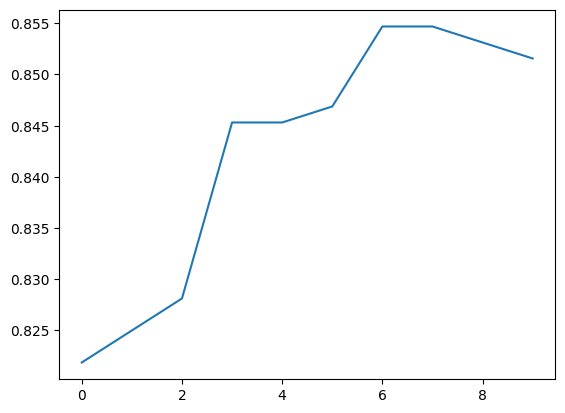

In [48]:
plt.plot(history.history["accuracy"])

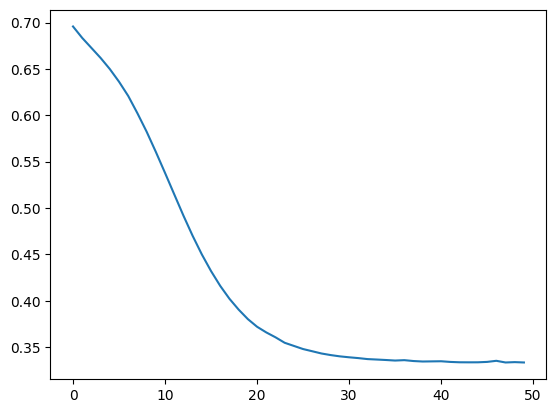

In [89]:
plt.plot(history.history["loss"])

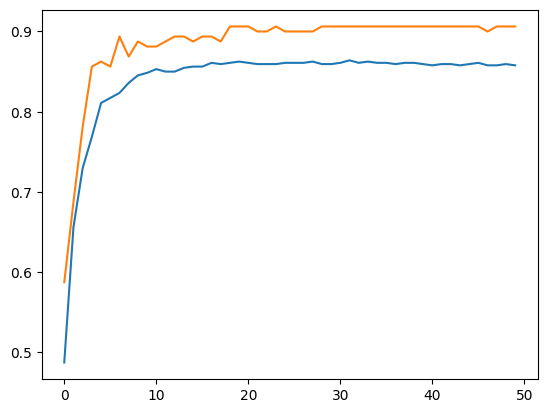

In [90]:

plt.plot(history.history["accuracy"])
plt.plot(history.history["val_accuracy"])

**Training through relu:**

In [91]:
model2=Sequential()
model2.add(Dense(16,activation="relu",input_dim=10))
model2.add(Dense(16,activation="relu"))
model2.add(Dense(1,activation="sigmoid"))


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [92]:
model2.summary()

Model: "sequential_8"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_20 (Dense)                │ (None, 16)             │           176 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_21 (Dense)                │ (None, 16)             │           272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_22 (Dense)                │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 465 (1.82 KB)

 Trainable params: 465 (1.82 KB)

 Non-trainable params: 0 (0.00 B)

In [93]:
model2.compile(optimizer="adam",loss="binary_crossentropy",metrics=["accuracy"])

In [94]:
history2=model2.fit(X_train,y_train,epochs=50,validation_split=0.2,verbose=1,batch_size=32)

Epoch 1/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 2s 30ms/step - accuracy: 0.4859 - loss: 0.7364 - val_accuracy: 0.4875 - val_loss: 0.6979
Epoch 2/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.6125 - loss: 0.6629 - val_accuracy: 0.7063 - val_loss: 0.6293
Epoch 3/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.7344 - loss: 0.6084 - val_accuracy: 0.8313 - val_loss: 0.5709
Epoch 4/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - accuracy: 0.8031 - loss: 0.5585 - val_accuracy: 0.8500 - val_loss: 0.5176
Epoch 5/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.8297 - loss: 0.5123 - val_accuracy: 0.8813 - val_loss: 0.4673
Epoch 6/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.8422 - loss: 0.4697 - val_accuracy: 0.9000 - val_loss: 0.4221
Epoch 7/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - accuracy: 0.8484 - loss: 0.4334 - val_accuracy: 0.9000 - val_loss: 0.3854
Epoch 8/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.8516 - loss: 0.4059 - val_accuracy: 0.9062 - va

In [95]:
y_pred_relu=model2.predict(X_test)

7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step


In [96]:
y_log_relu=np.where(y_pred_relu>0.5,1,0)

In [97]:
print(accuracy_score(y_test,y_log_relu))

0.84


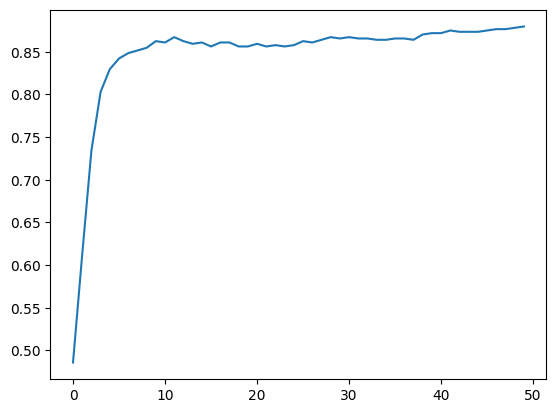

In [98]:
plt.plot(history2.history["accuracy"])

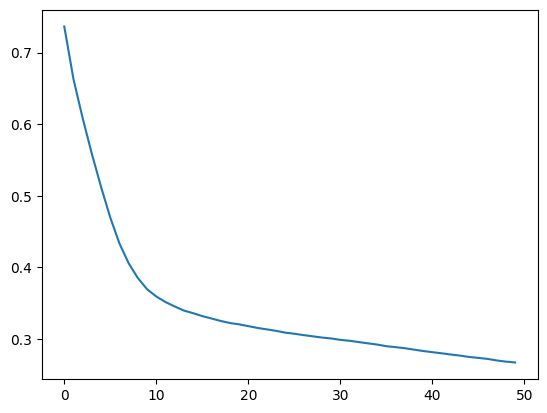

In [99]:
plt.plot(history2.history["loss"])

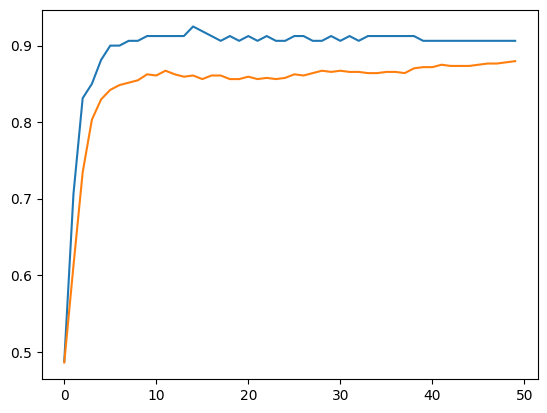

In [100]:
plt.plot(history2.history["val_accuracy"])
plt.plot(history2.history["accuracy"])


**Training through tanh**:


In [101]:
model3=Sequential()
model3.add(Dense(16,activation="tanh",input_dim=10))
model3.add(Dense(16,activation="tanh"))
model3.add(Dense(1,activation="sigmoid"))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [102]:
model3.summary()

Model: "sequential_9"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_23 (Dense)                │ (None, 16)             │           176 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_24 (Dense)                │ (None, 16)             │           272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_25 (Dense)                │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 465 (1.82 KB)

 Trainable params: 465 (1.82 KB)

 Non-trainable params: 0 (0.00 B)

In [103]:
model3.compile(optimizer="adam",loss="binary_crossentropy",metrics=["accuracy"])


In [104]:
history3=model3.fit(X_train,y_train,epochs=50,validation_split=0.2,verbose=1,batch_size=32)


Epoch 1/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 4s 44ms/step - accuracy: 0.5578 - loss: 0.7038 - val_accuracy: 0.7063 - val_loss: 0.6019
Epoch 2/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 35ms/step - accuracy: 0.7109 - loss: 0.5890 - val_accuracy: 0.7750 - val_loss: 0.5079
Epoch 3/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step - accuracy: 0.7891 - loss: 0.5122 - val_accuracy: 0.8250 - val_loss: 0.4404
Epoch 4/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - accuracy: 0.8062 - loss: 0.4563 - val_accuracy: 0.8750 - val_loss: 0.3916
Epoch 5/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.8391 - loss: 0.4138 - val_accuracy: 0.8875 - val_loss: 0.3560
Epoch 6/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.8547 - loss: 0.3848 - val_accuracy: 0.8938 - val_loss: 0.3309
Epoch 7/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.8609 - loss: 0.3651 - val_accuracy: 0.9062 - val_loss: 0.3131
Epoch 8/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.8609 - loss: 0.3514 - val_accuracy: 0.9000 - v

In [105]:
y_pred_tanh=model3.predict(X_test)


7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step 


In [106]:
y_log_tanh=np.where(y_pred_tanh>0.5,1,0)


In [107]:
accuracy_score(y_test,y_log_tanh)

0.87

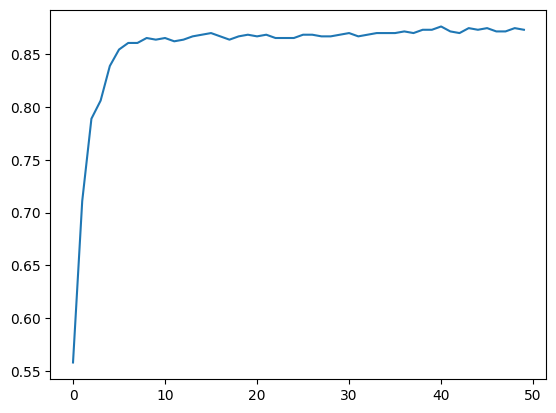

In [108]:
plt.plot(history3.history["accuracy"])

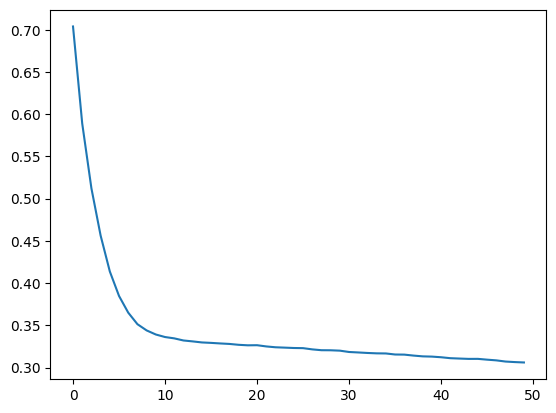

In [109]:
plt.plot(history3.history["loss"])


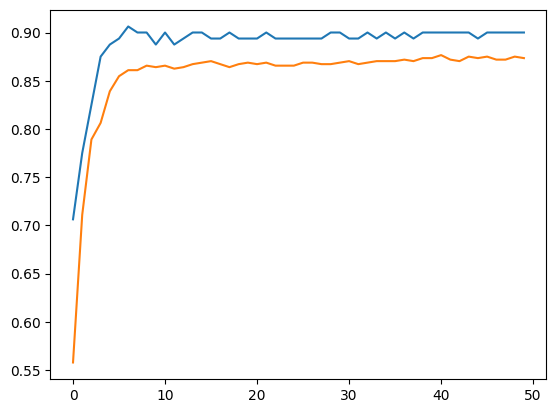

In [110]:
plt.plot(history3.history["val_accuracy"])
plt.plot(history3.history["accuracy"])



**Results Analysis:**

Sigmoid Accuracy: 88%  
Relu accuracy: 84%    
Tanh accuracy: 87%      
Sigmoid Performs best in shallower network because dataset is small

**Which showed slower learning?**   
 Tanh performs fastest and sigmoid slower ,Sigmoid took extra epochs to reach 80%

**What does val_accuracy and train_accuracy show? **

val_accuracy > train_accuracy in all 3 models → means the model is still generalizing well, no overfitting.

**Did any function fail?**
No

**Building deep network with 6-10 layers**:

In [111]:
model4=Sequential()
model4.add(Dense(16,activation="sigmoid",input_dim=10))
model4.add(Dense(16,activation="sigmoid"))
model4.add(Dense(16,activation="sigmoid"))
model4.add(Dense(16,activation="sigmoid"))
model4.add(Dense(16,activation="sigmoid"))
model4.add(Dense(16,activation="sigmoid"))
model4.add(Dense(16,activation="sigmoid"))
model4.add(Dense(16,activation="sigmoid"))
model4.add(Dense(16,activation="sigmoid"))
model4.add(Dense(1,activation="sigmoid"))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [112]:
model4.summary()

Model: "sequential_10"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_26 (Dense)                │ (None, 16)             │           176 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_27 (Dense)                │ (None, 16)             │           272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_28 (Dense)                │ (None, 16)             │           272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_29 (Dense)                │ (None, 16)             │           272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_30 (Dense)                │ (None, 16)             │           272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_31 (Dense)                │ (None, 16)             │           272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_32 (Dense)                │ (None, 16)             │           272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_33 (Dense)                │ (None, 16)             │           272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_34 (Dense)                │ (None, 16)             │           272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_35 (Dense)                │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,369 (9.25 KB)

 Trainable params: 2,369 (9.25 KB)

 Non-trainable params: 0 (0.00 B)

In [115]:
model4.compile(loss="binary_crossentropy",metrics=["accuracy"],optimizer="adam")


In [116]:
history4=model4.fit(X_train,y_train,epochs=50,validation_split=0.2,verbose=1,batch_size=32)


Epoch 1/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 4s 26ms/step - accuracy: 0.4844 - loss: 0.7316 - val_accuracy: 0.5250 - val_loss: 0.6965
Epoch 2/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.4844 - loss: 0.6985 - val_accuracy: 0.5250 - val_loss: 0.6924
Epoch 3/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.5250 - loss: 0.6927 - val_accuracy: 0.4750 - val_loss: 0.6960
Epoch 4/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.5156 - loss: 0.6930 - val_accuracy: 0.4750 - val_loss: 0.6953
Epoch 5/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.5156 - loss: 0.6933 - val_accuracy: 0.4750 - val_loss: 0.6963
Epoch 6/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.5156 - loss: 0.6931 - val_accuracy: 0.4750 - val_loss: 0.6942
Epoch 7/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.5156 - loss: 0.6934 - val_accuracy: 0.4750 - val_loss: 0.6957
Epoch 8/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.5156 - loss: 0.6930 - val_accuracy: 0.4750 - val_l

In [117]:
y_pred2_sigmoid=model4.predict(X_test)


7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step


In [118]:
y_log2_sigmoid=np.where(y_pred2_sigmoid>0.5,1,0)

In [119]:
print(accuracy_score(y_test,y_log2_sigmoid))

0.87


In [120]:
history4.history

{'accuracy': [0.484375,
  0.484375,
  0.5249999761581421,
  0.515625,
  0.515625,
  0.515625,
  0.515625,
  0.515625,
  0.515625,
  0.515625,
  0.515625,
  0.515625,
  0.515625,
  0.515625,
  0.515625,
  0.515625,
  0.515625,
  0.515625,
  0.515625,
  0.515625,
  0.515625,
  0.515625,
  0.515625,
  0.515625,
  0.515625,
  0.512499988079071,
  0.5625,
  0.515625,
  0.784375011920929,
  0.859375,
  0.8656250238418579,
  0.8687499761581421,
  0.8671875,
  0.870312511920929,
  0.871874988079071,
  0.8734375238418579,
  0.875,
  0.878125011920929,
  0.871874988079071,
  0.8765624761581421,
  0.8765624761581421,
  0.878125011920929,
  0.8812500238418579,
  0.875,
  0.875,
  0.875,
  0.8765624761581421,
  0.8828125,
  0.8812500238418579,
  0.8843749761581421],
 'loss': [0.7315582036972046,
  0.6985418200492859,
  0.6927229762077332,
  0.6929589509963989,
  0.693271279335022,
  0.6931453943252563,
  0.6933649778366089,
  0.6929836273193359,
  0.6928051114082336,
  0.6929059624671936,
  0.69385

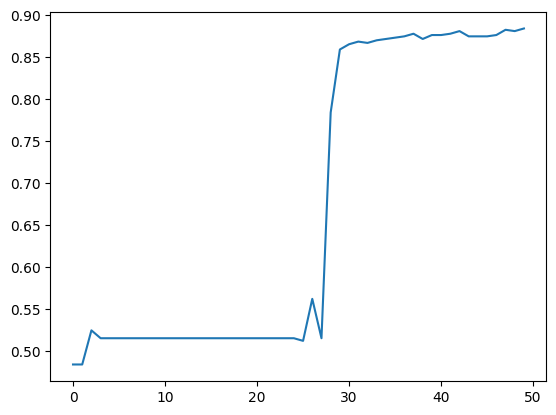

In [121]:
plt.plot(history4.history["accuracy"])

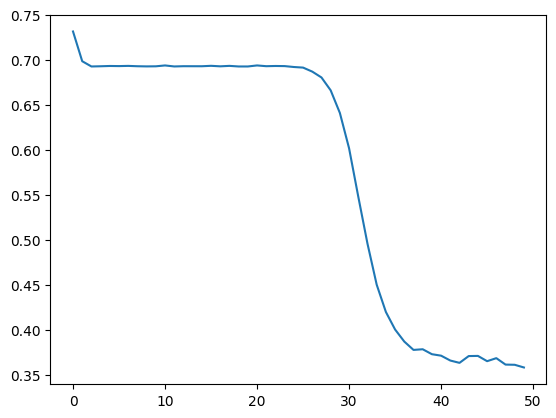

In [122]:
plt.plot(history4.history["loss"])


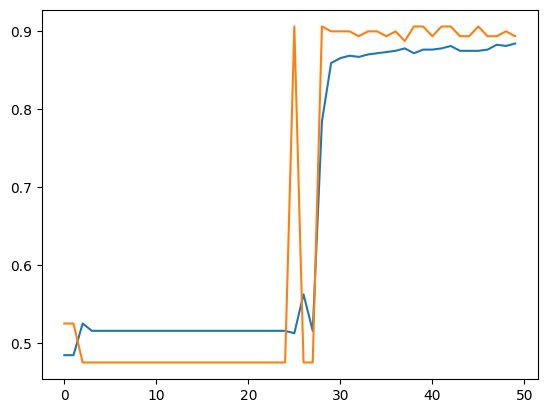

In [123]:
plt.plot(history4.history["accuracy"])
plt.plot(history4.history["val_accuracy"])


**Deeper network with relu:**

In [124]:
model5=Sequential()
model5.add(Dense(16,activation="relu",input_dim=10))
model.add(Dense(16,activation="relu"))
model5.add(Dense(16,activation="relu"))
model5.add(Dense(16,activation="relu"))
model5.add(Dense(16,activation="relu"))
model5.add(Dense(16,activation="relu"))
model5.add(Dense(16,activation="relu"))
model5.add(Dense(16,activation="relu"))
model.add(Dense(16,activation="relu"))
model5.add(Dense(1,activation="sigmoid"))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [125]:
model5.summary()

Model: "sequential_12"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_46 (Dense)                │ (None, 16)             │           176 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_48 (Dense)                │ (None, 16)             │           272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_49 (Dense)                │ (None, 16)             │           272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_50 (Dense)                │ (None, 16)             │           272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_51 (Dense)                │ (None, 16)             │           272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_52 (Dense)                │ (None, 16)             │           272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_53 (Dense)                │ (None, 16)             │           272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_55 (Dense)                │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,825 (7.13 KB)

 Trainable params: 1,825 (7.13 KB)

 Non-trainable params: 0 (0.00 B)

In [126]:
model5.compile(loss="binary_crossentropy",metrics=["accuracy"],optimizer="adam")


In [127]:
history5=model5.fit(X_train,y_train,epochs=50,validation_split=0.2,verbose=1,batch_size=32)


Epoch 1/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 3s 25ms/step - accuracy: 0.5281 - loss: 0.6861 - val_accuracy: 0.6438 - val_loss: 0.6702
Epoch 2/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.6828 - loss: 0.6570 - val_accuracy: 0.7063 - val_loss: 0.6295
Epoch 3/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.7250 - loss: 0.5947 - val_accuracy: 0.7375 - val_loss: 0.5383
Epoch 4/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.7937 - loss: 0.4835 - val_accuracy: 0.8188 - val_loss: 0.4404
Epoch 5/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.8359 - loss: 0.4035 - val_accuracy: 0.8250 - val_loss: 0.4150
Epoch 6/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.8453 - loss: 0.3690 - val_accuracy: 0.8313 - val_loss: 0.3789
Epoch 7/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.8516 - loss: 0.3591 - val_accuracy: 0.8313 - val_loss: 0.3836
Epoch 8/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.8641 - loss: 0.3424 - val_accuracy: 0.8500 - val_l

In [128]:
y_pred3_relu=model3.predict(X_test)


7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step 


In [129]:
y_log3_relu=np.where(y_pred3_relu>0.5,1,0)


In [130]:
print(accuracy_score(y_test,y_log3_relu))


0.87


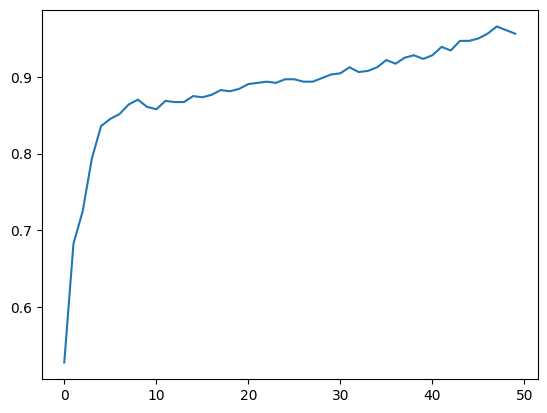

In [131]:
plt.plot(history5.history["accuracy"])


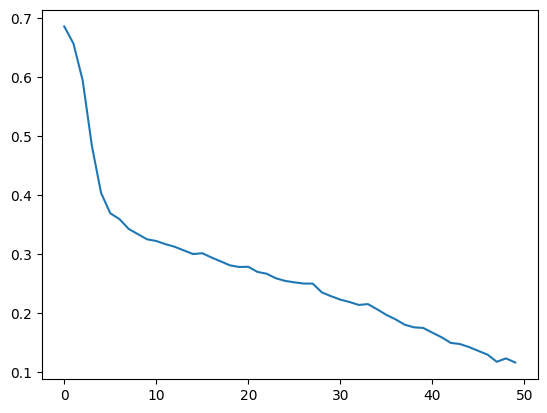

In [132]:
plt.plot(history5.history["loss"])


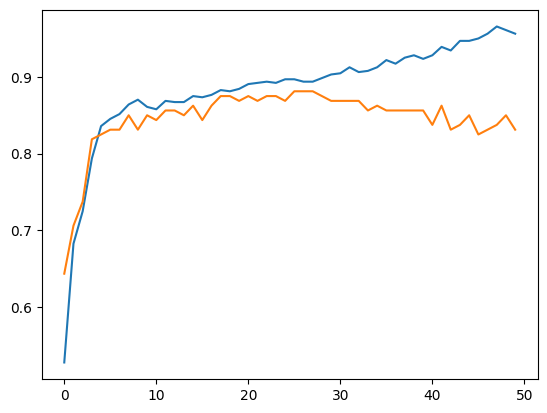

In [133]:
plt.plot(history5.history["accuracy"])
plt.plot(history5.history["val_accuracy"])


**Results Analysis:**

Relu performed better than sigmoid in deeper network.

Slowest → Sigmoid especially in deep networks

**Observation**:
In sigmoid:  

Vanishing gradients                                                                 
Saturation (values → 0 or 1)

In relu , accuracy>val_accuracy and gap between them is more than 10 so i observed overfitting here.

**Experiment with different optimizers:**

**Through SGD:**

In [137]:
model_opt=Sequential()
model_opt.add(Dense(16,activation="relu",input_dim=10))
model_opt.add(Dense(16,activation="relu"))
model_opt.add(Dense(1,activation="sigmoid"))



/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [138]:
model_opt.summary()

Model: "sequential_14"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_60 (Dense)                │ (None, 16)             │           176 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_61 (Dense)                │ (None, 16)             │           272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_62 (Dense)                │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 465 (1.82 KB)

 Trainable params: 465 (1.82 KB)

 Non-trainable params: 0 (0.00 B)

In [139]:
model5.compile(loss="binary_crossentropy",metrics=["accuracy"],optimizer="SGD")


In [145]:
history_opt=model5.fit(X_train,y_train,epochs=50,validation_split=0.2,verbose=1,batch_size=32)


Epoch 1/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - accuracy: 0.9578 - loss: 0.1181 - val_accuracy: 0.8125 - val_loss: 0.7051
Epoch 2/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9563 - loss: 0.1130 - val_accuracy: 0.8250 - val_loss: 0.6724
Epoch 3/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9609 - loss: 0.1164 - val_accuracy: 0.8438 - val_loss: 0.6750
Epoch 4/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9500 - loss: 0.1215 - val_accuracy: 0.8188 - val_loss: 0.6791
Epoch 5/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.9609 - loss: 0.1068 - val_accuracy: 0.8313 - val_loss: 0.6606
Epoch 6/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.9625 - loss: 0.1077 - val_accuracy: 0.8250 - val_loss: 0.6998
Epoch 7/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9688 - loss: 0.1000 - val_accuracy: 0.8438 - val_loss: 0.7145
Epoch 8/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9656 - loss: 0.1031 - val_accuracy: 0.8313 - val_lo

In [148]:
y_pred_opt=model_opt.predict(X_test)


7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step 


In [149]:
y_log_opt=np.where(y_pred_opt>0.5,1,0)

In [150]:
print(accuracy_score(y_test,y_log_opt))

0.445


In [151]:
history_opt.history

{'accuracy': [0.957812488079071,
  0.956250011920929,
  0.9609375,
  0.949999988079071,
  0.9609375,
  0.9624999761581421,
  0.96875,
  0.965624988079071,
  0.9546874761581421,
  0.949999988079071,
  0.9624999761581421,
  0.9453125,
  0.9546874761581421,
  0.9671875238418579,
  0.9671875238418579,
  0.965624988079071,
  0.973437488079071,
  0.96875,
  0.973437488079071,
  0.965624988079071,
  0.9703124761581421,
  0.973437488079071,
  0.9781249761581421,
  0.9750000238418579,
  0.973437488079071,
  0.973437488079071,
  0.9671875238418579,
  0.9546874761581421,
  0.965624988079071,
  0.9781249761581421,
  0.971875011920929,
  0.9765625,
  0.9624999761581421,
  0.957812488079071,
  0.9750000238418579,
  0.979687511920929,
  0.971875011920929,
  0.953125,
  0.9671875238418579,
  0.973437488079071,
  0.9671875238418579,
  0.965624988079071,
  0.9781249761581421,
  0.9828125238418579,
  0.9765625,
  0.9828125238418579,
  0.979687511920929,
  0.987500011920929,
  0.9828125238418579,
  0.9812

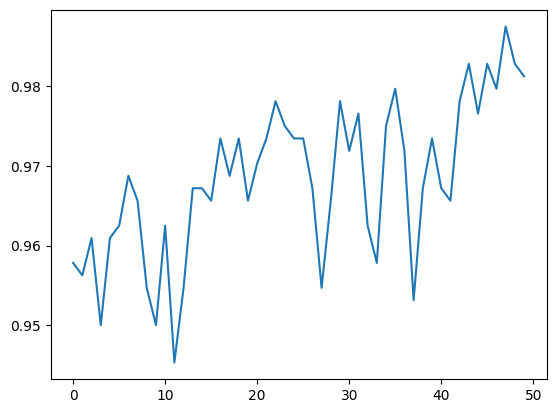

In [152]:
plt.plot(history_opt.history["accuracy"])

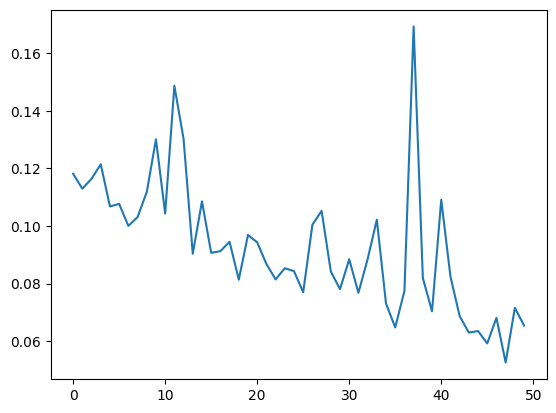

In [153]:
plt.plot(history_opt.history["loss"])


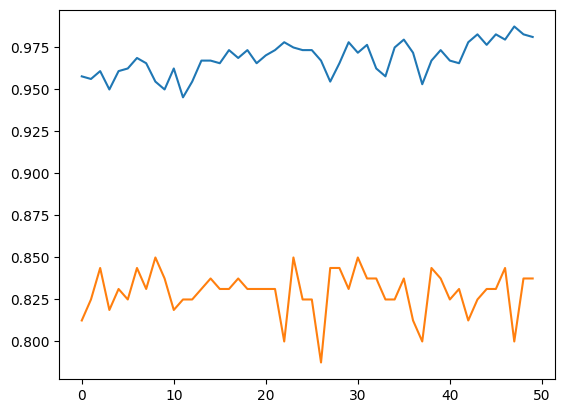

In [154]:
plt.plot(history_opt.history["accuracy"])
plt.plot(history_opt.history["val_accuracy"])


**through RMSprop optimizer:**

In [155]:
model_opt2=Sequential()
model_opt2.add(Dense(16,activation="relu",input_dim=10))
model_opt2.add(Dense(16,activation="relu"))

model_opt2.add(Dense(1,activation="sigmoid"))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [156]:
model_opt2.summary()

Model: "sequential_16"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_66 (Dense)                │ (None, 16)             │           176 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_67 (Dense)                │ (None, 16)             │           272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_68 (Dense)                │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 465 (1.82 KB)

 Trainable params: 465 (1.82 KB)

 Non-trainable params: 0 (0.00 B)

In [157]:
model_opt2.compile(loss="binary_crossentropy",metrics=["accuracy"],optimizer="RMSprop")


In [158]:
history_opt2=model5.fit(X_train,y_train,epochs=50,validation_split=0.2,verbose=1,batch_size=32)


Epoch 1/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9812 - loss: 0.0601 - val_accuracy: 0.8375 - val_loss: 0.8595
Epoch 2/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9766 - loss: 0.0695 - val_accuracy: 0.8313 - val_loss: 0.9048
Epoch 3/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9625 - loss: 0.1052 - val_accuracy: 0.8313 - val_loss: 0.8601
Epoch 4/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9812 - loss: 0.0535 - val_accuracy: 0.8313 - val_loss: 0.8814
Epoch 5/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9875 - loss: 0.0508 - val_accuracy: 0.8250 - val_loss: 0.9092
Epoch 6/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9641 - loss: 0.0971 - val_accuracy: 0.8438 - val_loss: 0.9042
Epoch 7/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9859 - loss: 0.0477 - val_accuracy: 0.8313 - val_loss: 0.9506
Epoch 8/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9859 - loss: 0.0513 - val_accuracy: 0.8375 - val_loss:

In [159]:
y_pred_opt2=model_opt2.predict(X_test)


7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step


In [160]:
y_log_opt2=np.where(y_pred_opt2>0.5,1,0)


In [161]:
accuracy_score(y_test,y_log_opt2)

0.275

In [162]:
history_opt2.history

{'accuracy': [0.981249988079071,
  0.9765625,
  0.9624999761581421,
  0.981249988079071,
  0.987500011920929,
  0.964062511920929,
  0.9859374761581421,
  0.9859374761581421,
  0.971875011920929,
  0.9781249761581421,
  0.987500011920929,
  0.9921875,
  0.981249988079071,
  0.981249988079071,
  0.964062511920929,
  0.9624999761581421,
  0.989062488079071,
  0.989062488079071,
  0.981249988079071,
  0.989062488079071,
  0.981249988079071,
  0.9859374761581421,
  0.9906250238418579,
  0.996874988079071,
  0.989062488079071,
  0.995312511920929,
  0.9921875,
  0.996874988079071,
  0.9828125238418579,
  0.9921875,
  0.987500011920929,
  0.9906250238418579,
  0.9984375238418579,
  0.989062488079071,
  0.9828125238418579,
  0.984375,
  0.9937499761581421,
  0.9937499761581421,
  0.9984375238418579,
  0.9781249761581421,
  0.995312511920929,
  0.9750000238418579,
  0.9609375,
  0.971875011920929,
  0.981249988079071,
  0.9859374761581421,
  0.995312511920929,
  0.996874988079071,
  0.99374997

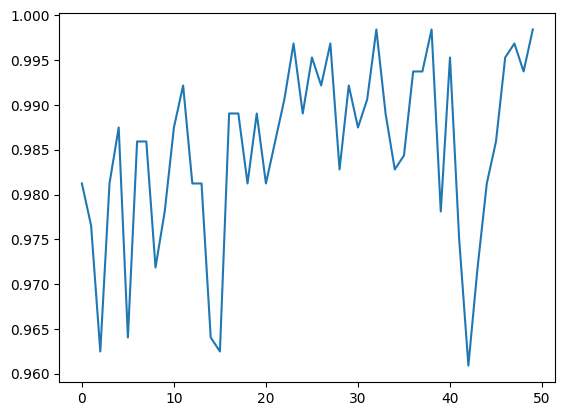

In [163]:
plt.plot(history_opt2.history["accuracy"])


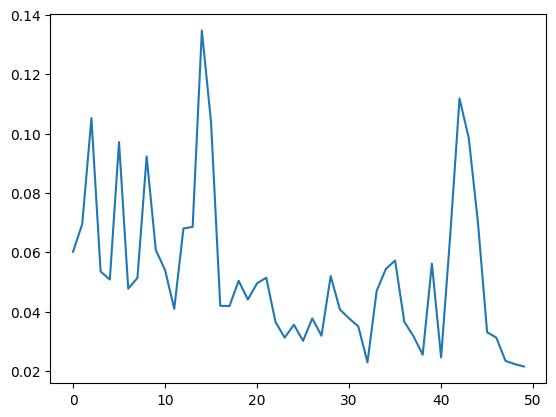

In [165]:
plt.plot(history_opt2.history["loss"])


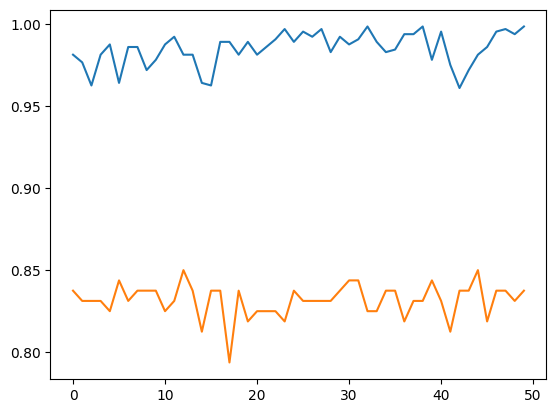

In [166]:
plt.plot(history_opt2.history["accuracy"])
plt.plot(history_opt2.history["val_accuracy"])



**Result Analysis:**

In both sgd and rmsprop ,drastic overfitting occured because model is performing well on training data but poor on validation data